In [1]:
import pandas as pd
import pickle

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astroML.datasets import fetch_sdss_specgals
from sklearn.model_selection import train_test_split
from astroML.utils.decorators import pickle_results

In [2]:
# Get the data
df = pd.DataFrame(fetch_sdss_specgals())

# Calculate the color indices
df['u-g'] = df['modelMag_u'] - df['modelMag_g']
df['g-r'] = df['modelMag_g'] - df['modelMag_r']
df['r-i'] = df['modelMag_r'] - df['modelMag_i']
df['i-z'] = df['modelMag_i'] - df['modelMag_z']

In [3]:
# Filtering Parameters
mag_err = 1
z_min = 0.02

# Filter the dataset
df_clean = df[
    (df['modelMagErr_u'] < mag_err) &
    (df['modelMagErr_g'] < mag_err) &
    (df['modelMagErr_r'] < mag_err) &
    (df['modelMagErr_i'] < mag_err) &
    (df['modelMagErr_z'] < mag_err) &
    (df['z'] > z_min)
]

# Define the X and y datasets
X = df_clean[['u-g', 'g-r', 'r-i', 'i-z']]
y = df_clean['z']

# Define the file path
file_path = f'data/dataset_clean.pkl'

# Using pickle to save the splits locally
@pickle_results(file_path)
def split_data(X_data, y_data):
    X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

# Run the function to generate and save the splits
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

# Save the full dataset (without splits)
with open('data/full_dataset_clean.pkl', 'wb') as file:
    pickle.dump(df_clean, file)

@pickle_results: computing results and saving to 'data/dataset_clean.pkl'


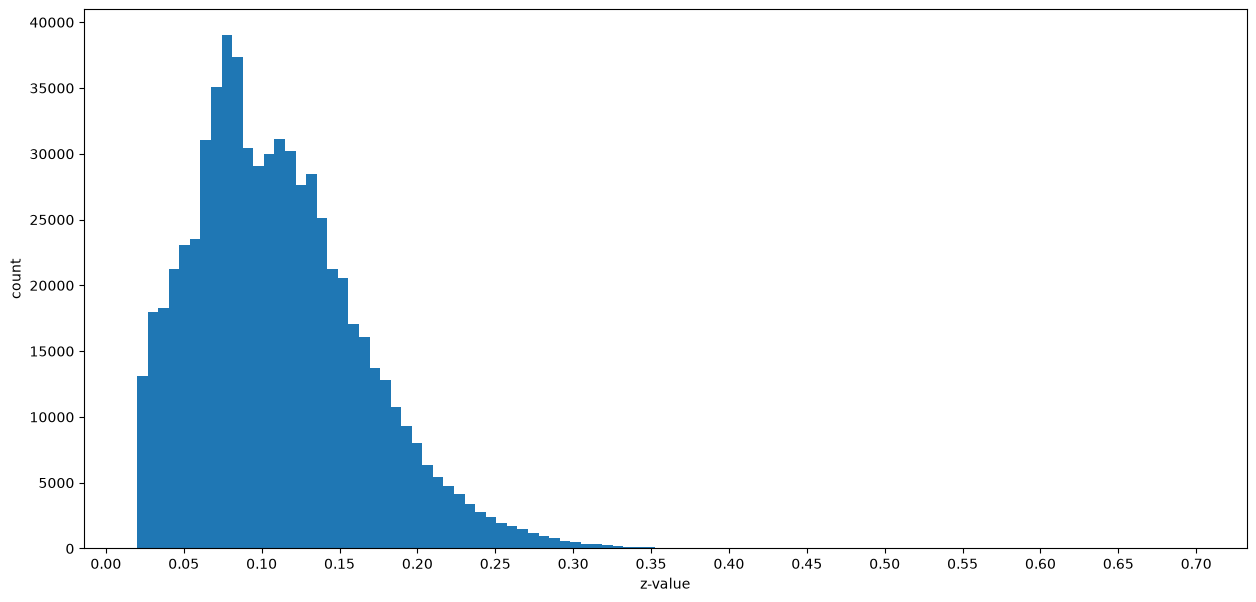

In [4]:
# --------------------
# Z-Value Distribution
# --------------------

# Create figure and axes objects
fig, ax = plt.subplots(figsize=(15,7))

# Plot the histogram
ax.hist(df['z'], bins=100)

# Force the x-axis to show a tick every 0.05 units
ax.xaxis.set_major_locator(MultipleLocator(0.05))

ax.set_xlabel("z-value")
ax.set_ylabel("count")
plt.show()